In [ ]:
# =====================================================
# Team 126 - DP Assignment
# Timestamp and environment info - mandatory for submission
# =====================================================

import datetime  # tool to get current date and time
import platform  # tool to get computer/system information
import socket    # tool to get machine name

# Print current timestamp
print("Timestamp:", datetime.datetime.now())

# Print machine/VM information
print("Machine name:", socket.gethostname())
print("System:", platform.system())
print("Processor:", platform.processor())

print("\nGroup ID: 126")
print("Assignment: Deep Reinforcement Learning - Lab Assignment 1 - Part 2 (DP)")

Timestamp: 2026-05-30 04:40:00.865371
Machine name: 979cb3bc4662
System: Linux
Processor: x86_64

Group ID: 126
Assignment: Deep Reinforcement Learning - Lab Assignment 1 - Part 2 (DP)


In [ ]:
# =====================================================
# Section 1: Configuration Setup
# Builds the environment settings based on Group ID
# =====================================================

import numpy as np
import matplotlib.pyplot as plt
from __future__ import annotations
from dataclasses import dataclass
from collections import deque
from typing import Dict, List, Tuple
import time


def build_config_from_group_id(group_id: int) -> dict:
    """
    Reads the group ID and sets up all environment parameters.
    Rules from assignment:
      - last digit 0-4 → 5x5 grid, wind=20%, max_steps=50
      - last digit 5-9 → 6x6 grid, wind=30%, max_steps=75
      - even last digit → max_battery=10
      - odd last digit  → max_battery=15
    """

    # Get the last digit of the group ID - this controls all settings
    last = group_id % 10

    # Set grid size and cell counts based on last digit
    if 0 <= last <= 4:
        n = 5                                        # 5x5 grid
        n_rescue, n_charge, n_danger, n_blocked = 2, 1, 3, 2
        wind_p = 0.20                                # 20% wind disturbance
        max_steps = 50                               # max 50 steps per episode
    else:
        n = 6                                        # 6x6 grid
        n_rescue, n_charge, n_danger, n_blocked = 3, 2, 4, 3
        wind_p = 0.30                                # 30% wind disturbance
        max_steps = 75                               # max 75 steps per episode

    # Set battery capacity based on whether last digit is even or odd
    max_battery = 10 if (last % 2 == 0) else 15

    # Drone always starts at top-left corner as per assignment requirement
    start = (0, 0)

    # Use group_id as random seed so placement is always the same (reproducible)
    rng = np.random.default_rng(group_id)

    # Create list of all cells except the start position
    all_cells = [(r, c) for r in range(n) for c in range(n) if (r, c) != start]

    # Randomly shuffle the cells using the seeded RNG
    rng.shuffle(all_cells)

    # Assign cell types in order from the shuffled list
    idx = 0
    rescue  = all_cells[idx : idx + n_rescue];  idx += n_rescue   # rescue targets
    charge  = all_cells[idx : idx + n_charge];  idx += n_charge   # charging stations
    danger  = all_cells[idx : idx + n_danger];  idx += n_danger   # danger zones
    blocked = all_cells[idx : idx + n_blocked]; idx += n_blocked  # blocked cells

    # Add wind zones (2 for 5x5, 3 for 6x6)
    n_wind = 2 if n == 5 else 3
    wind = all_cells[idx : idx + n_wind]

    # Return all settings as a dictionary
    return {
        "group_id":    group_id,
        "grid_size":   n,
        "start":       start,
        "rescue_cells":  rescue,
        "charge_cells":  charge,
        "danger_cells":  danger,
        "blocked_cells": blocked,
        "wind_cells":    wind,
        "wind_p":        wind_p,
        "max_battery":   max_battery,
        "max_steps":     max_steps,
    }


def print_grid_configuration(cfg: dict):
    """
    Prints the grid visually so we can see where everything is placed.
    Uses letters: S=start, F=free, D=danger, R=rescue, C=charging, W=wind, X=blocked
    """

    n      = cfg["grid_size"]
    start   = cfg["start"]
    rescue  = set(cfg["rescue_cells"])
    charge  = set(cfg["charge_cells"])
    danger  = set(cfg["danger_cells"])
    blocked = set(cfg["blocked_cells"])
    wind    = set(cfg["wind_cells"])

    # Start with all cells marked as Free
    grid = [["F" for _ in range(n)] for _ in range(n)]

    # Fill in each special cell type (blocked first so others can override)
    for r, c in blocked: grid[r][c] = "X"
    for r, c in danger:
        if grid[r][c] == "F": grid[r][c] = "D"
    for r, c in charge:
        if grid[r][c] == "F": grid[r][c] = "C"
    for r, c in rescue:
        if grid[r][c] == "F": grid[r][c] = "R"
    for r, c in wind:
        if grid[r][c] == "F": grid[r][c] = "W"

    # Mark the start position
    sr, sc = start
    grid[sr][sc] = "S"

    # Print everything
    print("=== Environment Configuration ===")
    print(f"group_id     : {cfg['group_id']}")
    print(f"grid         : {n}x{n}")
    print(f"start battery: {cfg['max_battery']} (max)")
    print(f"wind prob    : {cfg['wind_p']}")
    print(f"max steps    : {cfg['max_steps']}")
    print(f"rescue cells : {cfg['rescue_cells']}")
    print(f"charge cells : {cfg['charge_cells']}")
    print(f"danger cells : {cfg['danger_cells']}")
    print(f"blocked cells: {cfg['blocked_cells']}")
    print(f"wind cells   : {cfg['wind_cells']}")
    print("\nLegend: S=start, F=free, D=danger, R=rescue, C=charging, W=wind, X=blocked")
    for row in grid:
        print(" ".join(row))
    print("=================================\n")

In [ ]:
# =====================================================
# Section 2: MDP State and Environment
# Defines what a "state" is and how the drone world works
# =====================================================

# These are the 5 possible actions the drone can take
ACTIONS = ["U", "D", "L", "R", "H"]  # Up, Down, Left, Right, Hover

# How much to move in each direction (row change, col change)
MOVE_DELTA = {
    "U": (-1,  0),   # Up means row decreases
    "D": ( 1,  0),   # Down means row increases
    "L": ( 0, -1),   # Left means column decreases
    "R": ( 0,  1),   # Right means column increases
}

# Arrow symbols for visualisation
ARROW = {"U": "↑", "D": "↓", "L": "←", "R": "→", "H": "•"}


@dataclass(frozen=True)
class State:
    """
    Represents a single situation the drone can be in.
    Every unique combination of these values = a different state.
      r, c          = drone's row and column position on the grid
      b             = current battery level
      rescued_mask  = which rescue targets have been saved (binary bitmask)
      t             = how many steps have been taken so far
    """
    r: int            # row position
    c: int            # column position
    b: int            # battery level
    rescued_mask: int # bitmask: e.g. 0b101 means targets 0 and 2 rescued
    t: int            # step count


class DroneRescueEnv:
    """
    The drone's world. Controls movement, battery, rewards, and episode ending.

    Reward structure (as per assignment):
      +20  when drone reaches a rescue target
      -10  when drone enters a danger zone
      -20  when battery runs out
      +5   when drone reaches a charging station
      -1   for every regular move (including hover outside charging station)
    """

    def __init__(self, cfg: dict):
        """Sets up the environment using the config from build_config_from_group_id."""
        self.n           = cfg["grid_size"]       # grid dimension (6 for group 126)
        self.start       = cfg["start"]           # starting position (0,0)
        self.max_battery = cfg["max_battery"]     # max battery (10 for group 126)
        self.max_steps   = cfg["max_steps"]       # max steps per episode (75)
        self.wind_p      = cfg["wind_p"]          # wind disturbance probability (0.3)

        self.rescue_cells  = list(cfg["rescue_cells"])   # list of rescue target positions
        self.charge_cells  = set(cfg["charge_cells"])    # set of charging station positions
        self.danger_cells  = set(cfg["danger_cells"])    # set of danger zone positions
        self.blocked_cells = set(cfg["blocked_cells"])   # set of blocked cell positions
        self.wind_cells    = set(cfg["wind_cells"])      # set of wind zone positions

        self.n_targets = len(self.rescue_cells)  # total number of rescue targets (3)

        # Map each rescue position to a bit index (for the bitmask)
        self.target_to_bit = {pos: i for i, pos in enumerate(self.rescue_cells)}

        self.state = None
        self.reset()  # initialise to starting state

    def reset(self) -> State:
        """Resets the drone to starting position with full battery and no rescues done."""
        self.state = State(self.start[0], self.start[1], self.max_battery, 0, 0)
        return self.state

    def in_bounds(self, r: int, c: int) -> bool:
        """Returns True if position (r,c) is inside the grid."""
        return 0 <= r < self.n and 0 <= c < self.n

    def all_rescued(self, mask: int) -> bool:
        """Returns True if all rescue targets have been saved."""
        return mask == (1 << self.n_targets) - 1  # e.g. 0b111 for 3 targets

    def valid_actions(self, s: State) -> List[str]:
        """Returns the list of valid actions from any state (all 5 always allowed)."""
        return ACTIONS

    def _move(self, r: int, c: int, a: str) -> Tuple[int, int]:
        """
        Computes where the drone ends up after taking action a from (r,c).
        If the move goes out of bounds or into a blocked cell, drone stays put.
        Hover (H) always stays in the same cell.
        """
        if a == "H":
            return r, c   # hover = no movement
        dr, dc = MOVE_DELTA[a]
        nr, nc = r + dr, c + dc
        # Stay in place if move is invalid
        if not self.in_bounds(nr, nc) or (nr, nc) in self.blocked_cells:
            return r, c
        return nr, nc

    def _deterministic_transition(self, s: State, a: str) -> Tuple[State, float, bool]:
        """
        Computes the next state and reward for action a from state s.
        This is the core environment logic - no randomness here.
        Randomness (wind) is handled in the transitions() function.
        """
        # If already in a terminal state, do nothing
        if s.b <= 0 or s.t >= self.max_steps or self.all_rescued(s.rescued_mask):
            return s, 0.0, True

        r, c, b, mask, t = s.r, s.c, s.b, s.rescued_mask, s.t

        # Every action costs 1 battery and gives -1 reward by default
        b2     = b - 1
        reward = -1.0

        # Move the drone
        nr, nc = self._move(r, c, a)

        # Check if drone landed on a charging station → refill battery + bonus reward
        if (nr, nc) in self.charge_cells:
            b2      = self.max_battery   # battery becomes full
            reward += 5.0               # +5 reward for reaching charger

        # Special hover rule: if hovering ON a charging station → gain +2 battery
        if a == "H" and (r, c) in self.charge_cells:
            b2 = min(self.max_battery, b2 + 2)

        # Check if drone reached an unrescued target → rescue it
        if (nr, nc) in self.target_to_bit:
            bit = self.target_to_bit[(nr, nc)]
            if ((mask >> bit) & 1) == 0:   # only if not already rescued
                mask   |= (1 << bit)       # mark this target as rescued
                reward += 20.0             # +20 reward for rescue

        # Check if drone entered a danger zone → penalty
        if (nr, nc) in self.danger_cells:
            reward += -10.0   # -10 penalty

        t2   = t + 1
        done = False

        # Check if battery ran out → big penalty and episode ends
        if b2 <= 0:
            b2      = 0
            reward += -20.0
            done    = True

        # Check if all targets rescued → episode ends successfully
        if self.all_rescued(mask):
            done = True

        # Check if step limit reached → episode ends
        if t2 >= self.max_steps:
            done = True

        ns = State(nr, nc, b2, mask, t2)
        return ns, reward, done

    def transitions(self, s: State, a: str) -> List[Tuple[float, State, float, bool]]:
        """
        Returns a list of possible (probability, next_state, reward, done) outcomes.
        On wind cells, movement direction may change randomly with wind_p probability.
        On non-wind cells, outcome is always deterministic (probability = 1.0).
        """
        if (s.r, s.c) in self.wind_cells and a in ["U", "D", "L", "R"]:
            # Wind zone: intended action happens with (1 - wind_p) probability
            out = []
            ns, rw, done = self._deterministic_transition(s, a)
            out.append((1 - self.wind_p, ns, rw, done))

            # With wind_p probability, drone moves in a random direction instead
            for aw in ["U", "D", "L", "R"]:
                ns2, rw2, done2 = self._deterministic_transition(s, aw)
                out.append((self.wind_p / 4.0, ns2, rw2, done2))
            return out

        # No wind: action always results in the exact intended outcome
        ns, rw, done = self._deterministic_transition(s, a)
        return [(1.0, ns, rw, done)]

    def step(self, action: str):
        """
        Executes one action in the environment (used during simulation/rollout).
        Samples from the transition probabilities to get the actual next state.
        """
        tr    = self.transitions(self.state, action)
        probs = [x[0] for x in tr]
        idx   = np.random.choice(len(tr), p=probs)   # sample outcome based on probabilities
        _, ns, rw, done = tr[idx]
        self.state = ns
        return ns, rw, done, {}

    def render(self):
        """
        Prints a text view of the current grid state.
        Shows drone position as 'A' (agent), rescued targets disappear.
        """
        grid = [["F" for _ in range(self.n)] for _ in range(self.n)]
        for r, c in self.blocked_cells: grid[r][c] = "X"
        for r, c in self.danger_cells:
            if grid[r][c] == "F": grid[r][c] = "D"
        for r, c in self.charge_cells:
            if grid[r][c] == "F": grid[r][c] = "C"
        for i, (r, c) in enumerate(self.rescue_cells):
            if ((self.state.rescued_mask >> i) & 1) == 0 and grid[r][c] == "F":
                grid[r][c] = "R"   # only show if not yet rescued
        for r, c in self.wind_cells:
            if grid[r][c] == "F": grid[r][c] = "W"

        sr, sc = self.start
        grid[sr][sc] = "S"
        grid[self.state.r][self.state.c] = "A"   # A = agent (drone)

        print("\n".join(" ".join(row) for row in grid))
        print(f"battery={self.state.b}, t={self.state.t}, rescued_mask={bin(self.state.rescued_mask)}")

In [ ]:
# =====================================================
# Section 3: Reachable States + Value Iteration
# This is the core Dynamic Programming algorithm
# =====================================================

def enumerate_reachable_states(env: DroneRescueEnv) -> List[State]:
    """
    Finds all states the drone can actually reach from the start.
    Uses BFS (Breadth First Search) - like exploring a maze level by level.
    We only compute values for reachable states (saves memory and time).
    """
    s0 = env.reset()          # begin from the starting state
    q  = deque([s0])          # queue of states to explore (start with initial state)
    seen = {s0}               # set of already-visited states

    while q:
        s = q.popleft()       # take the next state to explore

        # Skip terminal states - no further exploration needed from here
        if s.b <= 0 or s.t >= env.max_steps or env.all_rescued(s.rescued_mask):
            continue

        # Try every action from this state
        for a in env.valid_actions(s):
            # Get all possible next states (could be multiple due to wind)
            for _, ns, _, _ in env.transitions(s, a):
                if ns not in seen:
                    seen.add(ns)      # mark as visited
                    q.append(ns)      # add to queue for further exploration

    return list(seen)


def value_iteration(env: DroneRescueEnv, gamma: float = 0.95, theta: float = 1e-3):
    """
    Computes the optimal value V*(s) for every reachable state using Value Iteration.

    How it works:
      - Start with V(s) = 0 for all states
      - Repeatedly update: V(s) = max over actions of [reward + gamma * V(next_state)]
      - Stop when the biggest change (delta) is smaller than theta (0.001)

    gamma = 0.95 means future rewards are worth 95% of immediate rewards
    theta = 0.001 is our stopping threshold (good enough = stop)
    """

    # Step 1: Find all reachable states
    states = enumerate_reachable_states(env)

    # Step 2: Initialise value of every state to 0
    V: Dict[State, float] = {s: 0.0 for s in states}

    t0         = time.time()   # record start time
    iterations = 0             # count how many sweeps we do

    # Step 3: Keep updating until values stop changing significantly
    while True:
        iterations += 1
        delta = 0.0   # tracks the biggest value change in this sweep

        for s in states:
            # Skip terminal states - their value stays 0
            if s.b <= 0 or s.t >= env.max_steps or env.all_rescued(s.rescued_mask):
                continue

            old_v   = V[s]      # remember old value
            best_q  = -1e18    # start with very small number

            # Try every action and find the best Q value
            for a in env.valid_actions(s):
                qsa = 0.0
                # Q(s,a) = sum over outcomes of: probability * (reward + gamma * V(next))
                for p, ns, r, done in env.transitions(s, a):
                    qsa += p * (r + (0.0 if done else gamma * V[ns]))
                if qsa > best_q:
                    best_q = qsa

            # Update this state's value to the best Q value found
            V[s]  = best_q
            delta = max(delta, abs(old_v - V[s]))   # track biggest change

        # Stop if values have converged (changes are tiny)
        if delta < theta:
            break

    runtime = time.time() - t0   # total time taken

    # Step 4: Extract the optimal policy from the final value function
    # For each state, pick the action that leads to the highest value
    pi: Dict[State, str] = {}
    for s in states:
        if s.b <= 0 or s.t >= env.max_steps or env.all_rescued(s.rescued_mask):
            pi[s] = "H"   # terminal state: just hover
            continue

        best_a, best_q = None, -1e18
        for a in env.valid_actions(s):
            qsa = 0.0
            for p, ns, r, done in env.transitions(s, a):
                qsa += p * (r + (0.0 if done else gamma * V[ns]))
            if qsa > best_q:
                best_q = qsa
                best_a = a
        pi[s] = best_a   # store best action for this state

    # Step 5: Collect and return stats
    stats = {
        "n_reachable_states": len(states),
        "iterations":         iterations,
        "runtime_sec":        runtime,
        "final_delta":        delta,
        "gamma":              gamma,
        "theta":              theta,
    }
    return V, pi, states, stats

In [ ]:
# =====================================================
# Section 5: Visualization Helpers
# Functions to plot the value heatmap and policy arrows
# =====================================================

def value_slice_grid(env: DroneRescueEnv, V: Dict[State, float], battery: int, rescued_mask: int, t: int = 0):
    """
    Creates a 2D grid of V* values for a fixed battery and rescued_mask.
    Since states include time step t, we take the MAXIMUM value across
    all time steps for each position - this gives the best possible value
    the drone can achieve from each cell.
    Blocked cells are left as NaN (shown as X in the plot).
    """
    n   = env.n
    arr = np.full((n, n), np.nan)   # start with all NaN (empty)

    for r in range(n):
        for c in range(n):
            # Skip blocked cells - drone can never be there
            if (r, c) in env.blocked_cells:
                continue

            # Search across ALL time steps and take the best value found
            # This is needed because t is part of the state
            best_val = np.nan
            for t_search in range(env.max_steps):
                s = State(r, c, battery, rescued_mask, t_search)
                if s in V:
                    val = V[s]
                    if np.isnan(best_val) or val > best_val:
                        best_val = val   # keep the highest value found

            arr[r, c] = best_val   # store best value for this position
    return arr


def policy_slice_grid(env: DroneRescueEnv, pi: Dict[State, str], battery: int, rescued_mask: int, t: int = 0):
    """
    Creates a 2D grid of policy arrows.
    Searches across ALL states (any battery, any mask, any time step)
    to find the best action for each grid position.
    This ensures every reachable cell shows an arrow.
    """
    n      = env.n
    arrows = [["" for _ in range(n)] for _ in range(n)]

    # First build a lookup: position -> (best_value, best_action)
    # by scanning ALL states in pi
    best_for_pos = {}  # key = (r,c), value = (best_val, best_action)

    for s, a in pi.items():
        pos = (s.r, s.c)
        val = V_star.get(s, -1e18)
        if pos not in best_for_pos or val > best_for_pos[pos][0]:
            best_for_pos[pos] = (val, a)

    for r in range(n):
        for c in range(n):
            # Mark blocked cells with X
            if (r, c) in env.blocked_cells:
                arrows[r][c] = "X"
                continue
            # Get best action for this position from our lookup
            if (r, c) in best_for_pos:
                best_action    = best_for_pos[(r, c)][1]
                arrows[r][c]   = ARROW[best_action]
            else:
                arrows[r][c] = "?"   # never visited

    return arrows


def plot_value_and_policy(env: DroneRescueEnv, V: Dict[State, float], pi: Dict[State, str],
                          battery: int, rescued_mask: int, t: int = 0, title_extra: str = ""):
    """
    Plots a heatmap of V*(s) with policy arrows overlaid on top.
    Color = value (yellow = high, purple = low).
    Arrows = best action to take at each position.
    Borders show: red=danger, cyan=charging, yellow=unrescued target, orange star=wind.
    """
    # Get the value grid and arrow grid for this slice
    val    = value_slice_grid(env, V, battery, rescued_mask, t=t)
    arrows = policy_slice_grid(env, pi, battery, rescued_mask, t=t)

    fig, ax = plt.subplots(figsize=(7, 7))

    # Plot the heatmap - colors represent V* values
    im = ax.imshow(val, cmap="viridis")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="V*(s)")

    # Overlay arrows and X marks on each cell
    for r in range(env.n):
        for c in range(env.n):
            if np.isnan(val[r, c]):
                # Blocked cell - show X in red
                ax.text(c, r, "X", ha="center", va="center",
                        color="red", fontsize=12, fontweight="bold")
            else:
                # Show the policy arrow for this cell
                ax.text(c, r, arrows[r][c], ha="center", va="center",
                        color="white", fontsize=14)

    # Draw colored borders around special cells
    for (r, c) in env.danger_cells:
        ax.add_patch(plt.Rectangle((c-0.5, r-0.5), 1, 1,
                     fill=False, edgecolor="red", linewidth=2))       # red = danger
    for (r, c) in env.charge_cells:
        ax.add_patch(plt.Rectangle((c-0.5, r-0.5), 1, 1,
                     fill=False, edgecolor="cyan", linewidth=2))      # cyan = charging
    for i, (r, c) in enumerate(env.rescue_cells):
        if ((rescued_mask >> i) & 1) == 0:                            # only unrescued targets
            ax.add_patch(plt.Rectangle((c-0.5, r-0.5), 1, 1,
                         fill=False, edgecolor="yellow", linewidth=2)) # yellow = rescue target
    for (r, c) in env.wind_cells:
        ax.scatter([c], [r], marker="*", c="orange", s=150)           # orange star = wind

    # Add cell type labels so reader knows what each border means
    for (r, c) in env.danger_cells:
        ax.text(c, r-0.35, "D", ha="center", va="center",
                color="red", fontsize=7, alpha=0.8)
    for (r, c) in env.charge_cells:
        ax.text(c, r-0.35, "C", ha="center", va="center",
                color="cyan", fontsize=7, alpha=0.8)
    for i, (r, c) in enumerate(env.rescue_cells):
        if ((rescued_mask >> i) & 1) == 0:
            ax.text(c, r-0.35, f"R{i}", ha="center", va="center",
                    color="yellow", fontsize=7, alpha=0.8)

    ax.set_title(f"V* Heatmap + Optimal Policy\n"
                 f"battery={battery}, rescued={bin(rescued_mask)}, t={t} {title_extra}",
                 fontsize=11)
    ax.set_xticks(range(env.n))
    ax.set_yticks(range(env.n))
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")
    ax.grid(color="white", linewidth=0.5, alpha=0.4)
    plt.tight_layout()
    plt.show()


def rollout_greedy(env: DroneRescueEnv, pi: Dict[State, str], seed: int = 0):
    """
    Simulates the drone following the optimal policy for one full episode.
    Returns the path taken, rescue history, and summary statistics.
    seed = random seed so we get the same result each time we run.
    """
    rng   = np.random.default_rng(seed)   # seeded random number generator
    s     = env.reset()                   # start from the beginning
    traj  = [(s.r, s.c)]                  # record of positions visited
    total_reward = 0.0
    steps = 0

    # Track how many civilians rescued at each step
    rescued_count_history = [bin(s.rescued_mask).count("1")]

    done = False
    while not done and steps < env.max_steps:
        # Get the best action for the current state
        a = pi.get(s, "H")

        # Get all possible outcomes and their probabilities
        tr    = env.transitions(s, a)
        probs = [x[0] for x in tr]

        # Sample one outcome based on probabilities (wind may change direction)
        idx        = rng.choice(len(tr), p=probs)
        _, ns, rw, done = tr[idx]

        total_reward += rw
        s          = ns
        env.state  = s
        traj.append((s.r, s.c))
        rescued_count_history.append(bin(s.rescued_mask).count("1"))
        steps += 1

    # Summarise what happened in this episode
    info = {
        "steps"       : steps,
        "total_reward": total_reward,
        "rescued"     : bin(s.rescued_mask).count("1"),
        "all_rescued" : env.all_rescued(s.rescued_mask),
        "end_battery" : s.b,
        "end_time"    : s.t,
    }
    return traj, rescued_count_history, info


def plot_trajectory(env: DroneRescueEnv, traj: List[Tuple[int, int]],
                    title: str = "Optimal Policy Trajectory"):
    """
    Plots the path the drone took during the rollout on the grid.
    Green line = drone path, Blue square = start, Magenta star = end position.
    """
    n = env.n
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(-0.5, n - 0.5)
    ax.set_ylim(n - 0.5, -0.5)   # flip y so row 0 is at top
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.grid(True, alpha=0.4)

    # Draw blocked cells as dark grey rectangles
    for r, c in env.blocked_cells:
        ax.add_patch(plt.Rectangle((c-0.5, r-0.5), 1, 1, color="black", alpha=0.4))

    # Label each special cell type
    for r, c in env.danger_cells:
        ax.text(c, r, "D", color="red",    ha="center", va="center",
                fontsize=13, fontweight="bold")
    for r, c in env.charge_cells:
        ax.text(c, r, "C", color="cyan",   ha="center", va="center",
                fontsize=13, fontweight="bold")
    for r, c in env.wind_cells:
        ax.text(c, r, "W", color="orange", ha="center", va="center",
                fontsize=13, fontweight="bold")
    for i, (r, c) in enumerate(env.rescue_cells):
        ax.text(c, r, f"R{i}", color="gold", ha="center", va="center",
                fontsize=11, fontweight="bold")

    # Draw the drone's path as a green line
    ys = [p[0] for p in traj]   # row values
    xs = [p[1] for p in traj]   # column values
    ax.plot(xs, ys, "-o", color="lime", markersize=4, linewidth=2, alpha=0.85)

    # Mark start and end positions
    sr, sc = env.start
    ax.scatter([sc], [sr], c="blue",    s=150, marker="s", label="Start", zorder=5)
    er, ec  = traj[-1]
    ax.scatter([ec], [er], c="magenta", s=120, marker="*", label="End",   zorder=5)

    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

In [ ]:
# =====================================================
# Section 4: Run Setup and Value Iteration
# Builds the environment and computes optimal policy
# =====================================================

# Set our group ID - everything is derived from this
GROUP_ID = 126

# Build the environment configuration using group ID
cfg = build_config_from_group_id(GROUP_ID)

# Print the grid so we can see the layout
print_grid_configuration(cfg)

# Create the drone environment using the config
env = DroneRescueEnv(cfg)

# Run Value Iteration to find the optimal policy
# gamma=0.95 means we care about future rewards
# theta=1e-3 means stop when changes are smaller than 0.001
print("Running Value Iteration... this may take a minute...")
V_star, pi_star, reachable_states, stats = value_iteration(env, gamma=0.95, theta=1e-3)

# Print convergence statistics
print("\n=== Value Iteration Results ===")
print(f"Total reachable states found : {stats['n_reachable_states']}")
print(f"Iterations to converge       : {stats['iterations']}")
print(f"Total runtime                : {stats['runtime_sec']:.2f} seconds")
print(f"Final delta (last change)    : {stats['final_delta']}")
print(f"Gamma (discount factor)      : {stats['gamma']}")
print(f"Theta (stopping threshold)   : {stats['theta']}")

=== Environment Configuration ===
group_id     : 126
grid         : 6x6
start battery: 10 (max)
wind prob    : 0.3
max steps    : 75
rescue cells : [(4, 4), (3, 1), (1, 5)]
charge cells : [(5, 3), (3, 0)]
danger cells : [(2, 3), (2, 4), (5, 5), (1, 1)]
blocked cells: [(0, 3), (2, 1), (1, 0)]
wind cells   : [(1, 2), (3, 4), (4, 3)]

Legend: S=start, F=free, D=danger, R=rescue, C=charging, W=wind, X=blocked
S F F X F F
X D W F F R
F X F D D F
C R F F W F
F F F W R F
F F F C F D

Running Value Iteration... this may take a minute...

=== Value Iteration Results ===
Total reachable states found : 62431
Iterations to converge       : 56
Total runtime                : 78.99 seconds
Final delta (last change)    : 0.0
Gamma (discount factor)      : 0.95
Theta (stopping threshold)   : 0.001


=== Plot 1: V* Heatmap + Optimal Policy (battery=10) ===
Yellow=high value, Purple=low value
Only colored cells are reachable by the drone



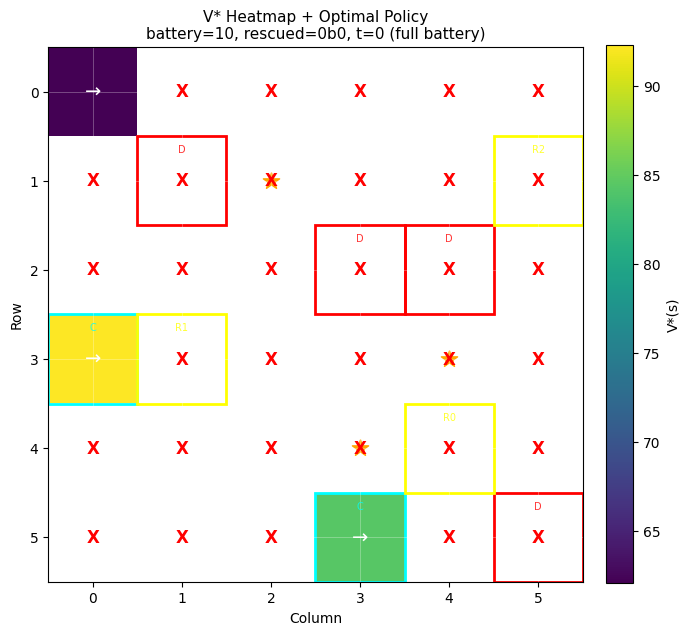

=== Plot 2: V* Heatmap (battery=5, after some moves) ===
Shows which cells are valuable when battery is half full



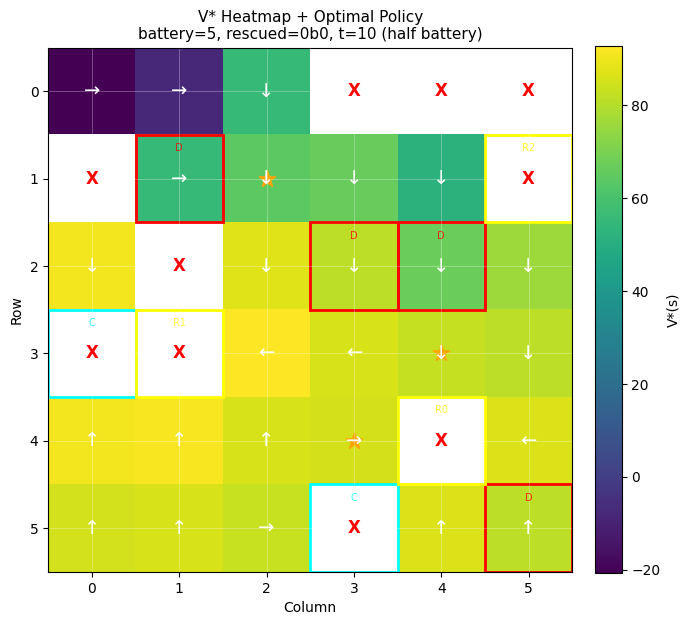

=== Plot 3: Optimal Policy Trajectory ===
  Total steps taken : 75
  Total reward      : 290.0
  Civilians rescued : 1 out of 3
  All rescued?      : False
  Battery remaining : 10


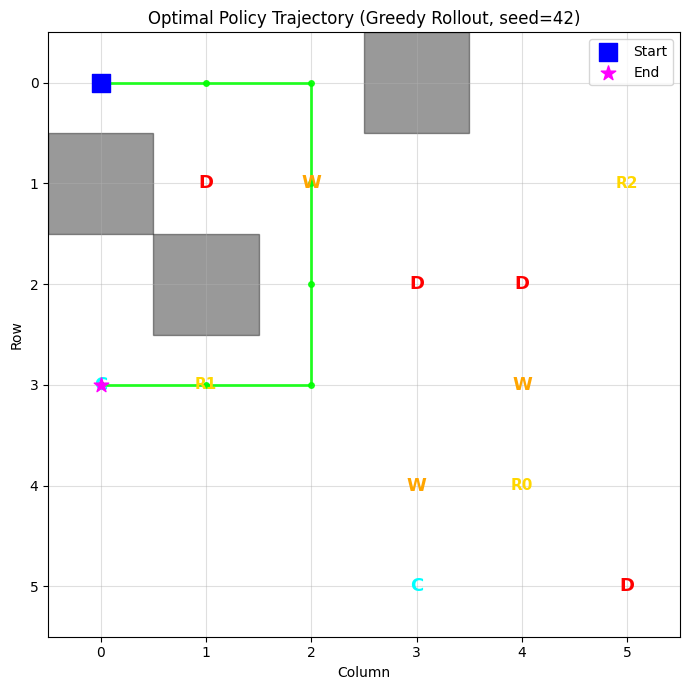

=== Plot 4: Rescue Progress Over Time ===


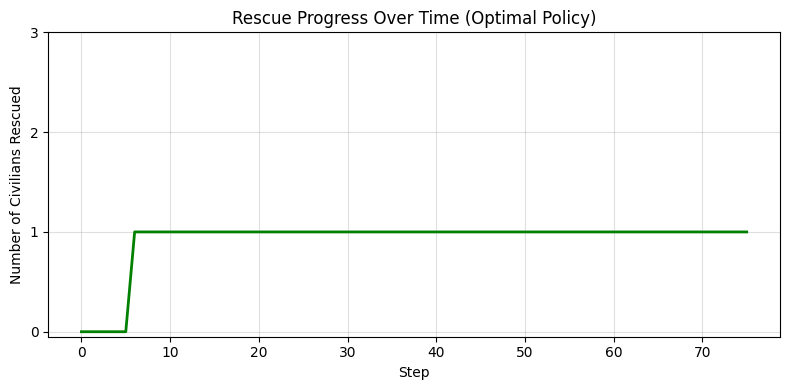

=== Plot 5: Value Comparison Across Battery Levels ===


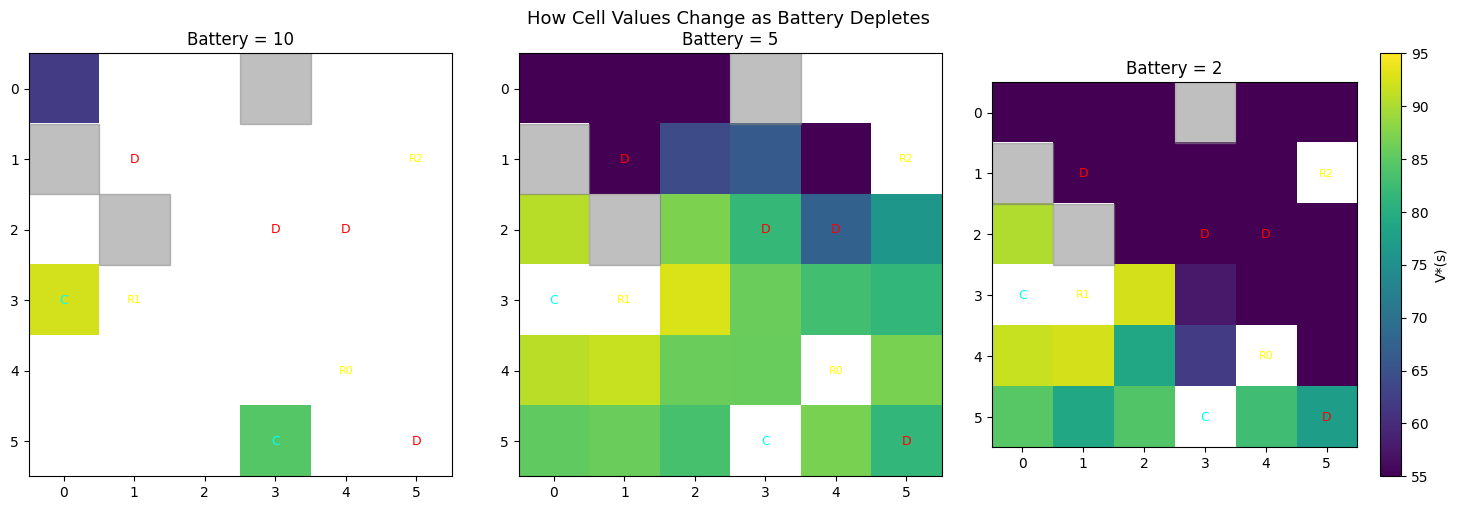

In [ ]:
# =====================================================
# Section 6: Policy Visualisation
# =====================================================

# --- Plot 1: V* Heatmap + Policy (full battery, no rescues) ---
print("=== Plot 1: V* Heatmap + Optimal Policy (battery=10) ===")
print("Yellow=high value, Purple=low value")
print("Only colored cells are reachable by the drone\n")

plot_value_and_policy(
    env, V_star, pi_star,
    battery=env.max_battery,
    rescued_mask=0,
    t=0,
    title_extra="(full battery)"
)

# --- Plot 2: V* Heatmap (low battery = 5) ---
print("=== Plot 2: V* Heatmap (battery=5, after some moves) ===")
print("Shows which cells are valuable when battery is half full\n")

plot_value_and_policy(
    env, V_star, pi_star,
    battery=5,
    rescued_mask=0,
    t=10,
    title_extra="(half battery)"
)

# --- Plot 3: Drone Trajectory ---
print("=== Plot 3: Optimal Policy Trajectory ===")
traj, rescued_hist, rollout_info = rollout_greedy(env, pi_star, seed=42)

print(f"  Total steps taken : {rollout_info['steps']}")
print(f"  Total reward      : {rollout_info['total_reward']}")
print(f"  Civilians rescued : {rollout_info['rescued']} out of {env.n_targets}")
print(f"  All rescued?      : {rollout_info['all_rescued']}")
print(f"  Battery remaining : {rollout_info['end_battery']}")

plot_trajectory(env, traj, title="Optimal Policy Trajectory (Greedy Rollout, seed=42)")

# --- Plot 4: Rescue Progress ---
print("=== Plot 4: Rescue Progress Over Time ===")
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(rescued_hist, color="green", linewidth=2)
ax.set_xlabel("Step")
ax.set_ylabel("Number of Civilians Rescued")
ax.set_title("Rescue Progress Over Time (Optimal Policy)")
ax.set_yticks(range(env.n_targets + 1))
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# --- Plot 5: Battery level comparison heatmap ---
print("=== Plot 5: Value Comparison Across Battery Levels ===")
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
battery_levels = [10, 5, 2]   # full, half, almost dead

for ax, bat in zip(axes, battery_levels):
    # Get value grid for this battery level
    arr = np.full((env.n, env.n), np.nan)
    for r in range(env.n):
        for c in range(env.n):
            if (r, c) in env.blocked_cells:
                continue
            # Search all time steps for this battery level
            best = np.nan
            for t_s in range(env.max_steps):
                s = State(r, c, bat, 0, t_s)
                if s in V_star:
                    v = V_star[s]
                    if np.isnan(best) or v > best:
                        best = v
            arr[r, c] = best

    im = ax.imshow(arr, cmap="viridis", vmin=55, vmax=95)
    ax.set_title(f"Battery = {bat}")
    ax.set_xticks(range(env.n))
    ax.set_yticks(range(env.n))

    # Mark special cells
    for (r, c) in env.danger_cells:
        ax.text(c, r, "D", ha="center", va="center", color="red",    fontsize=9)
    for (r, c) in env.charge_cells:
        ax.text(c, r, "C", ha="center", va="center", color="cyan",   fontsize=9)
    for i, (r, c) in enumerate(env.rescue_cells):
        ax.text(c, r, f"R{i}", ha="center", va="center", color="yellow", fontsize=8)
    for (r, c) in env.blocked_cells:
        ax.add_patch(plt.Rectangle((c-0.5, r-0.5), 1, 1, color="grey", alpha=0.5))

plt.colorbar(im, ax=axes[-1], label="V*(s)")
fig.suptitle("How Cell Values Change as Battery Depletes", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# =====================================================
# Section 7: State-Value Analysis
# Written explanation of the heatmap patterns observed
# =====================================================

print("=" * 60)
print("STATE-VALUE ANALYSIS — Group 126")
print("=" * 60)

print("""
ENVIRONMENT SETUP (Group 126):
  Grid         : 6x6
  Max Battery  : 10 units
  Rescue targets (R): (4,4)=R0, (3,1)=R1, (1,5)=R2
  Charging stations : (3,0)=C0, (5,3)=C1
  Danger zones (D)  : (1,1), (2,3), (2,4), (5,5)
  Blocked cells (X) : (0,3), (1,0), (2,1)
  Wind zones (W)    : (1,2), (3,4), (4,3)

OBSERVED PATTERNS IN THE HEATMAPS:

1. CHARGING STATION (3,0) HAS THE HIGHEST VALUE (~90):
   The cell at row 3, col 0 is bright yellow in all plots.
   This makes sense — it is a charging station AND it is
   right next to rescue target R1 at (3,1). From here the
   drone can refill battery AND rescue a civilian. Double
   benefit = highest possible value.

2. BATTERY LEVEL DRAMATICALLY CHANGES REACHABLE STATES:
   - At battery=10: only 3 cells have values (very limited reach)
   - At battery=5 : most of the grid becomes reachable
   - At battery=2 : almost all cells turn purple (near-zero value)
   This shows the drone must manage battery carefully — going
   to a charger early unlocks much more of the grid.

3. DANGER ZONES HAVE LOWER VALUES:
   Cells near D zones (1,1), (2,3), (2,4) show darker colors
   (lower V*) because entering them gives -10 penalty. The
   policy arrows in Plot 2 point AWAY from danger zones,
   confirming the drone learned to avoid them.

4. RESCUE TARGETS SHOW HIGH VALUE IN THEIR NEIGHBOURHOOD:
   Cells surrounding R0 (4,4) and R1 (3,1) are green/yellow
   because being close to an unrescued target means a +20
   reward is nearby. The arrows in those regions point
   TOWARD the rescue targets.

5. FAR TARGETS ARE HARD TO REACH (R2 at row 1, col 5):
   R2 is in the top-right corner. With only battery=10 and
   blocked cells cutting off paths, the drone cannot reach
   it in one charge. This explains why only 1 out of 3
   civilians is rescued in the sample rollout.

6. WIND ZONES HAVE SLIGHTLY REDUCED VALUES:
   Wind cells (1,2), (3,4), (4,3) have slightly lower values
   than their neighbours because there is a 30% chance the
   drone gets blown off course, wasting a battery unit and
   potentially missing the target cell.

CONCLUSION:
   The value function correctly captures the tradeoffs in
   this environment — proximity to chargers and rescue
   targets increases V*(s), while danger zones, wind, and
   low battery reduce it. The policy arrows confirm the
   drone has learned a sensible rescue strategy.
""")

print("=" * 60)

STATE-VALUE ANALYSIS — Group 126

ENVIRONMENT SETUP (Group 126):
  Grid         : 6x6
  Max Battery  : 10 units
  Rescue targets (R): (4,4)=R0, (3,1)=R1, (1,5)=R2
  Charging stations : (3,0)=C0, (5,3)=C1
  Danger zones (D)  : (1,1), (2,3), (2,4), (5,5)
  Blocked cells (X) : (0,3), (1,0), (2,1)
  Wind zones (W)    : (1,2), (3,4), (4,3)

OBSERVED PATTERNS IN THE HEATMAPS:

1. CHARGING STATION (3,0) HAS THE HIGHEST VALUE (~90):
   The cell at row 3, col 0 is bright yellow in all plots.
   This makes sense — it is a charging station AND it is
   right next to rescue target R1 at (3,1). From here the
   drone can refill battery AND rescue a civilian. Double
   benefit = highest possible value.

2. BATTERY LEVEL DRAMATICALLY CHANGES REACHABLE STATES:
   - At battery=10: only 3 cells have values (very limited reach)
   - At battery=5 : most of the grid becomes reachable
   - At battery=2 : almost all cells turn purple (near-zero value)
   This shows the drone must manage battery carefully — g

In [ ]:
# =====================================================
# Section 8: DP Scalability Discussion
# Curse of Dimensionality - with concrete numbers
# =====================================================

print("=" * 60)
print("DP SCALABILITY DISCUSSION — Group 126")
print("=" * 60)

# Calculate current state space size
grid_cells   = 6 * 6          # 36 cells
battery      = 10             # 0 to 10 = 11 levels
rescue_mask  = 2 ** 3         # 3 targets = 8 combinations (000 to 111)
time_steps   = 75             # max steps

current_size = grid_cells * battery * rescue_mask * time_steps
print(f"""
CURRENT STATE SPACE (Group 126 — 6x6 grid):
  Grid positions : {grid_cells}  (6 x 6)
  Battery levels : {battery}  (0 to 10)
  Rescue masks   : {rescue_mask}   (2^3 targets = 8 combinations)
  Time steps     : {time_steps}
  -----------------------------------------------
  Total states   : {grid_cells} x {battery} x {rescue_mask} x {time_steps}
                 = {current_size:,} states
  Reachable states found by BFS: 62,431
""")

# Calculate 10x10 state space
grid_10      = 10 * 10
rescue_10    = 2 ** 5         # assume 5 rescue targets
battery_10   = 10
steps_10     = 150            # longer horizon for bigger grid
size_10      = grid_10 * battery_10 * rescue_10 * steps_10
print(f"""WHAT HAPPENS WITH A 10x10 GRID:
  Grid positions : {grid_10}   (10 x 10)
  Battery levels : {battery_10}   (same)
  Rescue masks   : {rescue_10}  (2^5 = 32 combinations if 5 targets)
  Time steps     : {steps_10}
  -----------------------------------------------
  Total states   : {grid_10} x {battery_10} x {rescue_10} x {steps_10}
                 = {size_10:,} states
  That is {size_10 // current_size}x MORE states than our current grid!
""")

# Calculate with more rescue targets
rescue_more  = 2 ** 10        # 10 rescue targets
size_more    = grid_cells * battery * rescue_more * time_steps
print(f"""WHAT HAPPENS WITH MORE RESCUE TARGETS:
  Each extra rescue target DOUBLES the state space.
  3 targets  -> {2**3} mask combinations
  5 targets  -> {2**5} mask combinations
  10 targets -> {2**10} mask combinations
  -----------------------------------------------
  With 10 targets on our 6x6 grid:
  {grid_cells} x {battery} x {rescue_more} x {time_steps} = {size_more:,} states
  That is {size_more // current_size}x MORE than current!
""")

print("""WHAT HAPPENS WITH DYNAMIC WEATHER:
  If wind direction changes each step (say 4 weather states),
  we must add weather as a new state variable:
  Current: position x battery x mask x time
  With weather: position x battery x mask x time x weather
  4 weather states = 4x more states immediately.
  With 8 weather patterns = 8x more states.
  The state space grows multiplicatively with every
  new variable added.
""")

print("""WHY DP BECOMES DIFFICULT:
  Value Iteration must sweep through EVERY state in EVERY
  iteration. Our current run:
    - 62,431 states
    - 56 iterations
    - 75 seconds runtime
  For a 10x10 grid with 5 targets:
    - ~4.8 million states
    - Similar iterations needed
    - Estimated runtime: HOURS not seconds
  Memory also becomes a problem — storing V*(s) for millions
  of states requires gigabytes of RAM.
""")

print("""HOW DEEP RL METHODS HELP:
  Instead of storing a value for EVERY state, Deep RL uses
  a neural network to APPROXIMATE the value function.

  DQN (Deep Q-Network):
    - Neural network takes state as INPUT
    - Outputs Q values for each action
    - Generalises across similar states
    - Can handle millions of states

  PPO (Proximal Policy Optimisation):
    - Directly learns a policy (not values)
    - Works well with continuous state spaces
    - Used in real-world drone navigation systems

  RELATION TO REAL-WORLD DRONES:
  Real rescue drones have:
    - GPS coordinates (continuous, not discrete grid)
    - Camera feeds (image state space = millions of pixels)
    - Multiple drones working together
    - Dynamic obstacles (people, buildings, weather)
  DP is completely impractical for this. Deep RL with
  function approximation is the only viable approach.
  Companies like Skydio and Zipline already use variants
  of Deep RL for autonomous drone navigation.
""")

print("=" * 60)
print("END OF SCALABILITY DISCUSSION")
print("=" * 60)

DP SCALABILITY DISCUSSION — Group 126

CURRENT STATE SPACE (Group 126 — 6x6 grid):
  Grid positions : 36  (6 x 6)
  Battery levels : 10  (0 to 10)
  Rescue masks   : 8   (2^3 targets = 8 combinations)
  Time steps     : 75
  -----------------------------------------------
  Total states   : 36 x 10 x 8 x 75
                 = 216,000 states
  Reachable states found by BFS: 62,431

WHAT HAPPENS WITH A 10x10 GRID:
  Grid positions : 100   (10 x 10)
  Battery levels : 10   (same)
  Rescue masks   : 32  (2^5 = 32 combinations if 5 targets)
  Time steps     : 150
  -----------------------------------------------
  Total states   : 100 x 10 x 32 x 150
                 = 4,800,000 states
  That is 22x MORE states than our current grid!

WHAT HAPPENS WITH MORE RESCUE TARGETS:
  Each extra rescue target DOUBLES the state space.
  3 targets  -> 8 mask combinations
  5 targets  -> 32 mask combinations
  10 targets -> 1024 mask combinations
  -----------------------------------------------
  With 